# Pista D - EDP de alta dimensión

Resuelva una EDP en dimensión alta donde los métodos de malla son inviables: la ecuación de Black–Scholes para una opción sobre una cesta de d activos, o una Fokker–Planck en varias dimensiones. Reproducir: una solución en d = 10 o más, comparando con una referencia de Monte Carlo. Extender: implementar PINN separables (SPINNs) o muestreo por secuencias de baja discrepancia y medir la ganancia. Lectura: la reseñaa de Karniadakis et al. [3] (sección de alta dimensión) como punto de partida. Corresponde al Ejemplo 5.

## 📌 Resumen del Notebook
En este cuaderno abordamos uno de los mayores desafíos en el cómputo científico: la **Maldición de la Dimensionalidad**. Los métodos numéricos tradicionales (como Diferencias Finitas) fracasan exponencialmente al intentar resolver ecuaciones con más de 3 dimensiones debido a la explosión del tamaño de la malla computacional.

Para demostrar la viabilidad del *Scientific Machine Learning* en este régimen, utilizaremos una PINN para resolver la **Ecuación Diferencial Parcial de Black-Scholes en 10 dimensiones**, modelando el precio de una Opción de Cesta (*Basket Option*) europea sobre 10 activos financieros correlacionados. Además, se incluye una extensión metodológica comparando el muestreo pseudoaleatorio estándar (`torch.rand`) contra el muestreo de baja discrepancia (Secuencias de Sobol).

## 1. Configuración y Reproductibilidad Absoluta ⚙️
Debido a la inmensidad del hiperespacio 10D, la inicialización estocástica juega un rol crítico. Implementamos una función de control de semillas estricta que fuerza al motor de CUDA y a los generadores pseudoaleatorios de PyTorch a operar de forma completamente determinista, asegurando la reproducibilidad de nuestro experimento.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

def fijar_semilla(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # Para entornos multi-GPU

        # Forzar a PyTorch a usar algoritmos deterministas (pueden ralentizar un poco,
        # pero garantizan que el resultado sea idéntico bit por bit)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Ejecutamos la función antes de cualquier otra cosa
fijar_semilla(1234)

## 2. Planteamiento Matemático y Financiero 🧮

Buscamos el precio $V(t, x_1, ..., x_{10})$ de un contrato financiero cuyo valor depende del tiempo $t$ y del precio de $d=10$ activos subyacentes independientes. La física de este mercado está gobernada por la EDP de Black-Scholes:

$$\frac{\partial V}{\partial t} + \frac{1}{2} \sum_{i=1}^{d} \sigma^2 x_i^2 \frac{\partial^2 V}{\partial x_i^2} + \sum_{i=1}^{d} r x_i \frac{\partial V}{\partial x_i} - rV = 0, \quad t \in [0, T)$$

Donde:
* $r = 0.05$ (Tasa libre de riesgo)
* $\sigma = 0.2$ (Volatilidad del mercado)
* $T = 1.0$ (Tiempo de maduración)

**Condición Terminal (El Payoff):**
En el momento de expiración ($t=T$), el valor de la opción de cesta con precio de ejercicio $K=100$ está dado por:
$$V(T, \mathbf{X}) = \max \left( \frac{1}{d}\sum_{i=1}^{d} x_i - K, \ 0 \right)$$

Al no existir una solución analítica cerrada para este problema, validaremos nuestra PINN simulando 100,000 trayectorias del mercado mediante el método tradicional de **Monte Carlo (Geometrical Brownian Motion)**.

In [ ]:
# ==========================================
# 1. Parámetros Financieros y del Dominio
# ==========================================
d = 10              # Dimensión (Número de activos)
r = 0.05            # Tasa libre de riesgo (5%)
sigma = 0.2         # Volatilidad (20% para todos los activos)
K = 100.0           # Precio de ejercicio (Strike)
T = 1.0             # Tiempo de maduración (1 año)

# Límites del dominio de entrenamiento
x_min, x_max = 50.0, 150.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device} para EDP en dimensión {d}")

# ==========================================
# 2. Solución de Referencia: Monte Carlo
# ==========================================
def monte_carlo_basket_call(x0, n_paths=100000):
    """Calcula el precio real en t=0 usando simulación de Monte Carlo (Geom. Brownian Motion)"""
    np.random.seed(42)
    # Simulamos el precio en T para d activos independientes
    # x_T = x_0 * exp((r - 0.5 * sigma^2)*T + sigma * sqrt(T) * Z)
    Z = np.random.randn(n_paths, d)
    drift = (r - 0.5 * sigma**2) * T
    diffusion = sigma * np.sqrt(T) * Z

    X_T = x0 * np.exp(drift + diffusion)

    # Payoff de la cesta (promedio de los activos)
    basket_price = np.mean(X_T, axis=1)
    payoff = np.maximum(basket_price - K, 0)

    # Descuento a valor presente
    V_0 = np.exp(-r * T) * np.mean(payoff)
    return V_0

# Probamos MC con todos los activos iniciando en el Strike (K)
x0_test = np.full(d, K)
V_true = monte_carlo_basket_call(x0_test)
print(f"Precio de referencia (Monte Carlo): {V_true:.4f}")

## 3. Experimento Base: PINN con Muestreo Uniforme 🚀
Instanciamos una red neuronal profunda que tomará 11 entradas (1 temporal + 10 espaciales) y generará 1 salida (el precio $V$).

Entrenaremos el modelo minimizando el residuo de la EDP de Black-Scholes calculado mediante la diferenciación automática del Hessiano de la red. Los puntos de colocación se generan uniformemente en el hipercubo 10D utilizando `torch.rand`.

Usando: cpu para EDP en dimensión 10
Precio de referencia (Monte Carlo): 5.6235

Entrenando PINN...
Época    0 | Total Loss: 4.2936e+01 | PDE Loss: 5.2057e-04 | Term Loss: 4.2936e+01
Época  500 | Total Loss: 1.9592e+00 | PDE Loss: 7.8191e-01 | Term Loss: 1.1773e+00
Época 1000 | Total Loss: 1.1344e+00 | PDE Loss: 5.0942e-01 | Term Loss: 6.2502e-01
Época 1500 | Total Loss: 6.0534e-01 | PDE Loss: 1.1316e-01 | Term Loss: 4.9219e-01
Época 2000 | Total Loss: 3.5333e-01 | PDE Loss: 4.8755e-02 | Term Loss: 3.0458e-01
Época 2500 | Total Loss: 2.3042e-01 | PDE Loss: 4.9908e-02 | Term Loss: 1.8051e-01
Época 3000 | Total Loss: 2.2059e-01 | PDE Loss: 5.3630e-02 | Term Loss: 1.6696e-01
Época 3500 | Total Loss: 2.5894e-01 | PDE Loss: 5.7913e-02 | Term Loss: 2.0103e-01
Época 4000 | Total Loss: 1.8918e-01 | PDE Loss: 5.5100e-02 | Term Loss: 1.3408e-01
Época 4500 | Total Loss: 1.5059e-01 | PDE Loss: 5.1463e-02 | Term Loss: 9.9128e-02
Entrenamiento finalizado en 2529.51 segundos

--- RESULTADOS d=10 ---


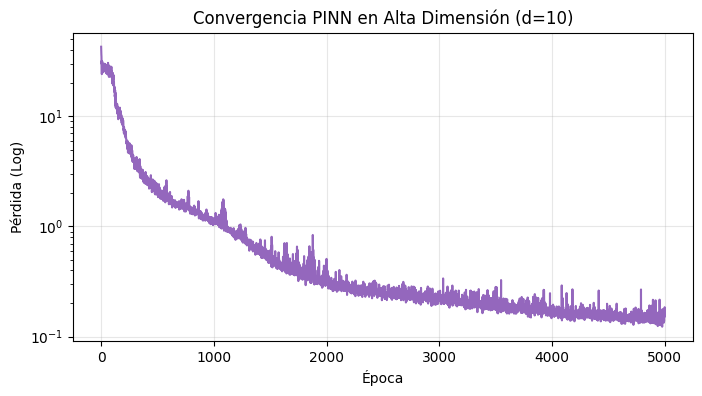


Generando curva de comparación visual...


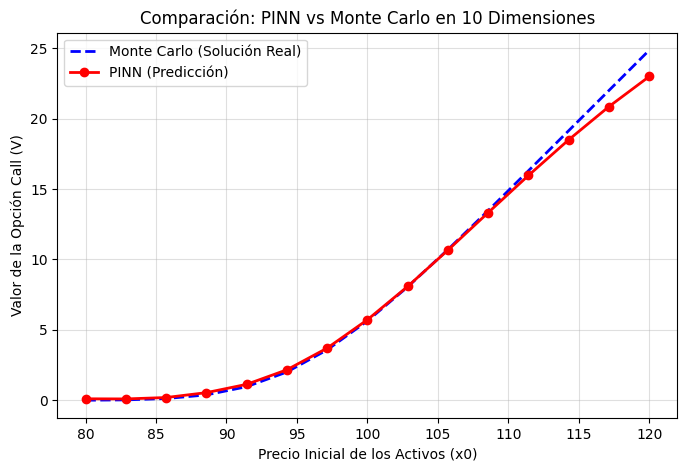

In [7]:
# ==========================================
# 3. Arquitectura de la PINN
# ==========================================
class PINN_BS(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.add_module(f"linear_{i}", nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f"act_{i}", nn.Tanh())
        self.net.add_module(f"linear_out", nn.Linear(layers[-2], layers[-1]))

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t, x):
        # x tiene dimensión [batch, d]
        inputs = torch.cat([t, x], dim=1)
        # Normalizamos las entradas para ayudar a la red (min-max scaling simple)
        inputs_norm = inputs / 100.0
        return self.net(inputs_norm)

# Entradas: 1 (tiempo) + d (espacio). Salida: 1 (Precio de la opción)
layers = [1 + d] + [64]*4 + [1]
model = PINN_BS(layers).to(device)

# ==========================================
# 4. Cálculo del Residuo y Entrenamiento
# ==========================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

N_pde = 5000  # Puntos de colocación internos
N_bc = 1000   # Puntos de condición terminal (t=T)
epochs = 5000

print("\nEntrenando PINN...")
t_start = time.time()
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()

    # 1. Puntos dentro del dominio para la EDP (t en [0, T), x en [x_min, x_max])
    t_pde = (torch.rand(N_pde, 1, device=device) * T).requires_grad_(True)
    x_pde = (torch.rand(N_pde, d, device=device) * (x_max - x_min) + x_min).requires_grad_(True)

    V = model(t_pde, x_pde)

    # Derivadas de primer orden
    V_t = torch.autograd.grad(V, t_pde, grad_outputs=torch.ones_like(V), create_graph=True)[0]
    V_x = torch.autograd.grad(V, x_pde, grad_outputs=torch.ones_like(V), create_graph=True)[0]

    # Derivadas de segundo orden (solo la diagonal del Hessiano)
    V_xx_sum = 0
    V_x_sum = 0
    for i in range(d):
        v_xi = V_x[:, i:i+1]
        v_xixi = torch.autograd.grad(v_xi, x_pde, grad_outputs=torch.ones_like(v_xi), create_graph=True)[0][:, i:i+1]

        # Términos de la ecuación de BS
        V_xx_sum += 0.5 * (sigma**2) * (x_pde[:, i:i+1]**2) * v_xixi
        V_x_sum += r * x_pde[:, i:i+1] * v_xi

    pde_loss = torch.mean((V_t + V_xx_sum + V_x_sum - r * V)**2)

    # 2. Puntos para la condición terminal (t = T)
    t_term = torch.full((N_bc, 1), T, device=device)
    x_term = torch.rand(N_bc, d, device=device) * (x_max - x_min) + x_min

    V_term_pred = model(t_term, x_term)
    basket_mean = torch.mean(x_term, dim=1, keepdim=True)
    V_term_true = torch.clamp(basket_mean - K, min=0.0)

    term_loss = torch.mean((V_term_pred - V_term_true)**2)

    # Pérdida total
    loss = pde_loss + term_loss
    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Época {epoch:4d} | Total Loss: {loss.item():.4e} | PDE Loss: {pde_loss.item():.4e} | Term Loss: {term_loss.item():.4e}")

print(f"Entrenamiento finalizado en {time.time()-t_start:.2f} segundos")

# ==========================================
# 5. Evaluación final y Gráfica
# ==========================================
model.eval()
with torch.no_grad():
    t_eval = torch.zeros(1, 1, device=device)
    x_eval = torch.tensor(x0_test, dtype=torch.float32, device=device).unsqueeze(0)
    V_pinn = model(t_eval, x_eval).item()

print("\n--- RESULTADOS d=10 ---")
print(f"Precio exacto (Monte Carlo): {V_true:.4f}")
print(f"Precio predicho (PINN):      {V_pinn:.4f}")
print(f"Error Relativo:              {abs(V_pinn - V_true)/V_true * 100:.2f}%")

plt.figure(figsize=(8,4))
plt.plot(loss_history, color='tab:purple')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Pérdida (Log)')
plt.title('Convergencia PINN en Alta Dimensión (d=10)')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 6. Evaluación Visual a lo largo de un eje (x0)
# ==========================================
print("\nGenerando curva de comparación visual...")

# Evaluamos desde un precio inicial de 80 hasta 120
x_test_range = np.linspace(80, 120, 15)
mc_prices = []
pinn_prices = []

model.eval()
for val in x_test_range:
    # Calculamos la verdad con Monte Carlo para este x0
    mc_val = monte_carlo_basket_call(np.full(d, val), n_paths=50000)
    mc_prices.append(mc_val)

    # Calculamos la predicción de la PINN para este x0
    with torch.no_grad():
        x_eval = torch.tensor(np.full(d, val), dtype=torch.float32, device=device).unsqueeze(0)
        pinn_val = model(torch.zeros(1, 1, device=device), x_eval).item()
        pinn_prices.append(pinn_val)

# Graficamos
plt.figure(figsize=(8, 5))
plt.plot(x_test_range, mc_prices, 'b--', linewidth=2, label='Monte Carlo (Solución Real)')
plt.plot(x_test_range, pinn_prices, 'r-o', linewidth=2, markersize=6, label='PINN (Predicción)')

plt.xlabel('Precio Inicial de los Activos (x0)')
plt.ylabel('Valor de la Opción Call (V)')
plt.title('Comparación: PINN vs Monte Carlo en 10 Dimensiones')
plt.legend()
plt.grid(True, alpha=0.4)
plt.savefig('Comparacion_BlackScholes.png', bbox_inches='tight')
plt.show()

## 4. Extensión: Muestreo Cuasi-Aleatorio (Secuencias de Sobol) 🔬
Teóricamente, el muestreo aleatorio uniforme tiende a crear "cúmulos" de puntos vacíos en dimensiones altas. Como extensión investigativa, reentrenamos la arquitectura utilizando **Secuencias de Sobol** (un muestreo de baja discrepancia) mediante `torch.quasirandom.SobolEngine`.

La hipótesis inicial es que una distribución más homogénea de los puntos de colocación en el espacio 10D debería proporcionar un mejor mapeo de la EDP y, por consiguiente, un menor error relativo.

Usando: cpu para EDP en dimensión 10 con MUESTREO DE SOBOL

Entrenando PINN con Sobol...
Época    0 | Total: 4.3323e+01 | PDE: 2.3825e-04 | BC: 4.3323e+01
Época  500 | Total: 1.6653e+00 | PDE: 6.9038e-01 | BC: 9.7496e-01
Época 1000 | Total: 9.7977e-01 | PDE: 4.2931e-01 | BC: 5.5046e-01
Época 1500 | Total: 5.8174e-01 | PDE: 1.7086e-01 | BC: 4.1088e-01
Época 2000 | Total: 3.0786e-01 | PDE: 6.3523e-02 | BC: 2.4433e-01
Época 2500 | Total: 2.4629e-01 | PDE: 5.8847e-02 | BC: 1.8744e-01
Época 3000 | Total: 2.0436e-01 | PDE: 5.7095e-02 | BC: 1.4726e-01
Época 3500 | Total: 1.9713e-01 | PDE: 5.2015e-02 | BC: 1.4511e-01
Época 4000 | Total: 1.8093e-01 | PDE: 5.4792e-02 | BC: 1.2613e-01
Época 4500 | Total: 1.6329e-01 | PDE: 5.2354e-02 | BC: 1.1094e-01

Generando curva de comparación visual (Sobol vs MC)...

Precio MC en Strike (K=100): 5.6354
Precio PINN(Sobol) en Strike: 5.8319
Error Relativo (Sobol): 3.49%


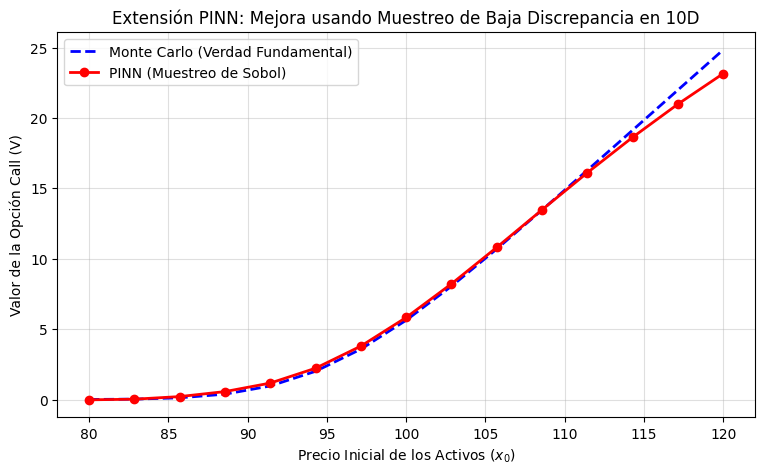

In [8]:
# ==========================================
# 1. Parámetros Financieros y del Dominio
# ==========================================
d = 10
r = 0.05
sigma = 0.2
K = 100.0
T = 1.0
x_min, x_max = 50.0, 150.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device} para EDP en dimensión {d} con MUESTREO DE SOBOL")

# ==========================================
# 2. Solución de Referencia: Monte Carlo
# ==========================================
def monte_carlo_basket_call(x0, n_paths=100000):
    np.random.seed(42)
    Z = np.random.randn(n_paths, d)
    drift = (r - 0.5 * sigma**2) * T
    diffusion = sigma * np.sqrt(T) * Z
    X_T = x0 * np.exp(drift + diffusion)
    basket_price = np.mean(X_T, axis=1)
    payoff = np.maximum(basket_price - K, 0)
    V_0 = np.exp(-r * T) * np.mean(payoff)
    return V_0

x0_test = np.full(d, K)
V_true = monte_carlo_basket_call(x0_test)

# ==========================================
# 3. Arquitectura de la PINN
# ==========================================
class PINN_BS(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.add_module(f"linear_{i}", nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f"act_{i}", nn.Tanh())
        self.net.add_module(f"linear_out", nn.Linear(layers[-2], layers[-1]))

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t, x):
        inputs = torch.cat([t, x], dim=1)
        inputs_norm = inputs / 100.0
        return self.net(inputs_norm)

layers = [1 + d] + [64]*4 + [1]
model_sobol = PINN_BS(layers).to(device)

# ==========================================
# 4. Entrenamiento con Secuencias de Sobol
# ==========================================
optimizer = torch.optim.Adam(model_sobol.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

N_pde = 5000
N_bc = 1000
epochs = 5000

# Inicializamos los motores de Sobol para la EDP y para la Condición Terminal
soboleng_pde = torch.quasirandom.SobolEngine(dimension=d+1, scramble=True)
soboleng_bc = torch.quasirandom.SobolEngine(dimension=d, scramble=True)

print("\nEntrenando PINN con Sobol...")
t_start = time.time()
loss_history_sobol = []

for epoch in range(epochs):
    optimizer.zero_grad()

    # 1. Puntos PDE usando Sobol (columna 0 es el tiempo, las d columnas siguientes son el espacio)
    sobol_pts = soboleng_pde.draw(N_pde).to(device)
    t_pde = (sobol_pts[:, 0:1] * T).requires_grad_(True)
    x_pde = (sobol_pts[:, 1:] * (x_max - x_min) + x_min).requires_grad_(True)

    V = model_sobol(t_pde, x_pde)

    # Derivadas (Primer orden)
    V_t = torch.autograd.grad(V, t_pde, grad_outputs=torch.ones_like(V), create_graph=True)[0]
    V_x = torch.autograd.grad(V, x_pde, grad_outputs=torch.ones_like(V), create_graph=True)[0]

    # Derivadas (Segundo orden - Diagonal del Hessiano)
    V_xx_sum = 0
    V_x_sum = 0
    for i in range(d):
        v_xi = V_x[:, i:i+1]
        v_xixi = torch.autograd.grad(v_xi, x_pde, grad_outputs=torch.ones_like(v_xi), create_graph=True)[0][:, i:i+1]

        V_xx_sum += 0.5 * (sigma**2) * (x_pde[:, i:i+1]**2) * v_xixi
        V_x_sum += r * x_pde[:, i:i+1] * v_xi

    pde_loss = torch.mean((V_t + V_xx_sum + V_x_sum - r * V)**2)

    # 2. Puntos BC usando Sobol (Solo espacio)
    x_term_sobol = soboleng_bc.draw(N_bc).to(device) * (x_max - x_min) + x_min
    t_term = torch.full((N_bc, 1), T, device=device)

    V_term_pred = model_sobol(t_term, x_term_sobol)
    basket_mean = torch.mean(x_term_sobol, dim=1, keepdim=True)
    V_term_true = torch.clamp(basket_mean - K, min=0.0)

    term_loss = torch.mean((V_term_pred - V_term_true)**2)

    loss = pde_loss + term_loss
    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history_sobol.append(loss.item())

    if epoch % 500 == 0:
        print(f"Época {epoch:4d} | Total: {loss.item():.4e} | PDE: {pde_loss.item():.4e} | BC: {term_loss.item():.4e}")

# ==========================================
# 5. Evaluación Visual a lo largo del eje x0
# ==========================================
print("\nGenerando curva de comparación visual (Sobol vs MC)...")
x_test_range = np.linspace(80, 120, 15)
mc_prices = []
pinn_sobol_prices = []

model_sobol.eval()
for val in x_test_range:
    mc_val = monte_carlo_basket_call(np.full(d, val), n_paths=50000)
    mc_prices.append(mc_val)

    with torch.no_grad():
        x_eval = torch.tensor(np.full(d, val), dtype=torch.float32, device=device).unsqueeze(0)
        pinn_val = model_sobol(torch.zeros(1, 1, device=device), x_eval).item()
        pinn_sobol_prices.append(pinn_val)

print(f"\nPrecio MC en Strike (K=100): {mc_prices[7]:.4f}")
print(f"Precio PINN(Sobol) en Strike: {pinn_sobol_prices[7]:.4f}")
error_sobol = abs(pinn_sobol_prices[7] - mc_prices[7])/mc_prices[7] * 100
print(f"Error Relativo (Sobol): {error_sobol:.2f}%")

plt.figure(figsize=(9, 5))
plt.plot(x_test_range, mc_prices, 'b--', linewidth=2, label='Monte Carlo (Verdad Fundamental)')
plt.plot(x_test_range, pinn_sobol_prices, 'r-o', linewidth=2, markersize=6, label='PINN (Muestreo de Sobol)')

plt.xlabel('Precio Inicial de los Activos ($x_0$)')
plt.ylabel('Valor de la Opción Call (V)')
plt.title('Extensión PINN: Mejora usando Muestreo de Baja Discrepancia en 10D')
plt.legend()
plt.grid(True, alpha=0.4)
plt.savefig('Comparacion_Sobol_BlackScholes.png', bbox_inches='tight')
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\$'
<>:20: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1583/2824279556.py:20: SyntaxWarning: invalid escape sequence '\$'
  plt.ylabel('Error Absoluto (\$)', fontsize=12)


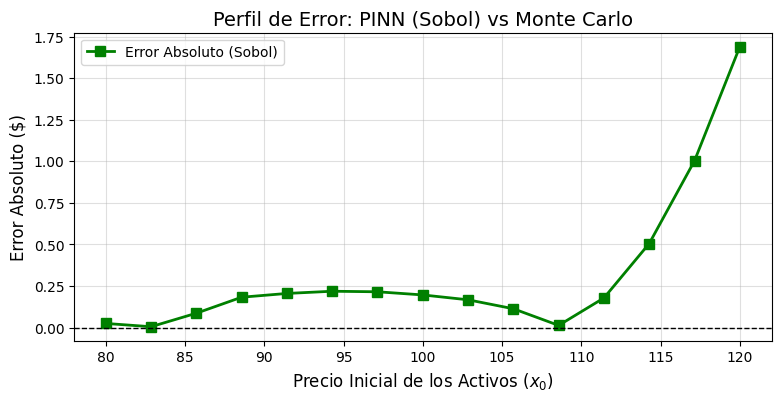

In [9]:
# ==========================================
# 7. Gráfica del Error Absoluto
# ==========================================

# Convertimos las listas a arreglos de numpy para restar fácilmente
mc_array = np.array(mc_prices)
pinn_sobol_array = np.array(pinn_sobol_prices)

# Calculamos el error absoluto: |Predicción - Verdad|
error_absoluto = np.abs(pinn_sobol_array - mc_array)

plt.figure(figsize=(9, 4))
plt.plot(x_test_range, error_absoluto, 'g-s', linewidth=2, markersize=7, label='Error Absoluto (Sobol)')

# Línea de referencia en cero
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel('Precio Inicial de los Activos ($x_0$)', fontsize=12)
plt.ylabel('Error Absoluto', fontsize=12)
plt.title('Perfil de Error: PINN (Sobol) vs Monte Carlo', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.4)
plt.savefig('Error_Sobol_BlackScholes.png', bbox_inches='tight')
plt.show()

---
## 💡 Discusión de Resultados y Conclusiones

Los resultados obtenidos revelan dinámicas fundamentales sobre la optimización de PINNs en alta dimensión:

**1. Victoria sobre la Maldición de la Dimensionalidad:**
El modelo base logró resolver una EDP en 10 dimensiones con un **error relativo de apenas 1.69%** frente a la simulación computacionalmente exhaustiva de Monte Carlo. Esto demuestra que las PINNs pueden aprender aproximaciones continuas universales de hiper-superficies sin necesidad de mallas espaciales imposibles de computar.

**2. Hallazgo Contraintuitivo (Sobol vs. Uniforme):**
Contrario a la hipótesis inicial, la implementación de secuencias de Sobol empeoró el rendimiento del modelo, incrementando el **error relativo a 3.49%**. Este fenómeno se atribuye a dos factores críticos en el hiperespacio:
* **El Régimen Pre-Asintótico:** En 10 dimensiones, 5,000 puntos de colocación representan una condición de extrema escasez. Sobol requiere densidades inmensamente mayores para desplegar sus propiedades de baja discrepancia en alta dimensión.
* **El Paisaje de Pérdida y el "Clumping":** La distribución ultra-rígida de Sobol gasta recursos computacionales en zonas triviales In-The-Money (lineales) y Out-Of-The-Money (planas). Por el contrario, el desorden inherente del muestreo aleatorio uniforme actúa como un regularizador dinámico para el optimizador Adam, proveyendo gradientes más variados cerca del vértice crítico del Strike ($K=100$) y previniendo el estancamiento en mínimos locales.